# Comparisons of BRICK projections (and hindcast) against AR6 and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, os
from matplotlib.patches import Patch

In [2]:
plt.style.use('tableau-colorblind10')

I'm grabbing the projections from my local dev folder, but you can set the `datdir` path to wherever you download and place the `projections_csv` folder from Zenodo (or generate on your own).

In [3]:
projdir = os.getcwd()
datdir = "/Users/aewsma/.julia/dev/MimiBRICK/results/projections_csv"
plotdir = projdir + "/figures"

In [4]:
if not os.path.exists(plotdir):
    os.makedirs(plotdir)
print("Will save plots to ",plotdir)

Will save plots to  /Users/aewsma/.julia/dev/MimiBRICK/examples/figures


In [5]:
panels = ["a.","b.","c.","d.","e.","f.","g.","h."]
scenarios = {"ssp119", "ssp126", "ssp245", "ssp370", "ssp585"}
scenarios_old = {"RCP26","RCP45","RCP85"}

In [6]:
model_configs = {"sneasybrick"}
# Could compare multiple model configurations too:
#model_configs = {"doeclimbrick", "sneasybrick"}
#model_configs = {"brick", "doeclimbrick", "sneasybrick"}

In [7]:
gis = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
ais = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
te = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
glac = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
lws = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
gmsl = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
temp = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
ocheat = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}
map = {model_config : {scen : pd.DataFrame() for scen in scenarios} for model_config in model_configs}

In [8]:
for model_config in model_configs:
    for scen in scenarios:
        gis[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_greenland_"+scen+"_"+model_config+".csv")
        ais[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_antarctic_"+scen+"_"+model_config+".csv")
        te[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_thermal_"+scen+"_"+model_config+".csv")
        glac[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_glaciers_"+scen+"_"+model_config+".csv")
        lws[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_landwater_storage_sl_"+scen+"_"+model_config+".csv")
        gmsl[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_gmsl_"+scen+"_"+model_config+".csv")
        temp[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_temperature_"+scen+"_"+model_config+".csv")
        ocheat[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_ocean_heat_"+scen+"_"+model_config+".csv")
        map[model_config][scen] = pd.read_csv(datdir+"/"+model_config+"/"+scen+"/projections_MAP_"+scen+"_"+model_config+".csv")

Get years and normalize relative to 1995-2014 mean (sea levels) and 1850-1900 mean (temperatures)

In [9]:
years = map[model_config]["ssp119"]["YEAR"]
map_slr_cols = ["GMSL", "LWS", "GLAC", "GIS", "AIS", "TE"]

def normalize(years, df, beg_year, end_year):
    ibeg = int(years.eq(beg_year).argmax())
    iend = int(years.eq(end_year).argmax())
    norm_means = df.iloc[ibeg:(iend+1)].mean()
    df -= norm_means
    return df

def normalize_columns(years, df, beg_year, end_year, cols):
    df = df.copy()
    ibeg = int(years.eq(beg_year).argmax())
    iend = int(years.eq(end_year).argmax())
    norm_means = df.loc[ibeg:iend, cols].mean()
    df.loc[:, cols] = df.loc[:, cols] - norm_means
    return df

for model_config in model_configs:
    for scen in scenarios:
        # new BRICK
        gis[model_config][scen] = normalize(years, gis[model_config][scen], 1995, 2014)
        ais[model_config][scen] = normalize(years, ais[model_config][scen], 1995, 2014)
        te[model_config][scen] = normalize(years, te[model_config][scen], 1995, 2014)
        glac[model_config][scen] = normalize(years, glac[model_config][scen], 1995, 2014)
        lws[model_config][scen] = normalize(years, lws[model_config][scen], 1995, 2014)
        gmsl[model_config][scen] = normalize(years, gmsl[model_config][scen], 1995, 2014)
        map[model_config][scen] = normalize_columns(years, map[model_config][scen], 1995, 2014, map_slr_cols)

calculate 17-83 percentile ranges in 2100 to compare to AR6

In [10]:
percs = [.17, .5, .83]
years_ar6 = [2030,2050,2090,2100,2150]
idx_year = {year : int(years.eq(year).argmax()) for year in years_ar6}
idx_2030 = int(years.eq(2030).argmax())
idx_2050 = int(years.eq(2050).argmax())
idx_2090 = int(years.eq(2090).argmax())
idx_2100 = int(years.eq(2100).argmax())
idx_2150 = int(years.eq(2150).argmax())

In [11]:
components = ["gis","ais","te","glac","lws","gmsl"]
source_dict = {"gis" : gis, "ais" : ais, "te" : te, "glac" : glac, "lws" : lws, "gmsl" : gmsl}
brick_likely = {model_config : {scen : {comp : np.zeros(len(percs)) for comp in components} for scen in scenarios} for model_config in model_configs}
old_new_scenario_map = {"ssp126" : "RCP26", "ssp245" : "RCP45", "ssp585" : "RCP85"} # if comparing RCPs too

for model_config in model_configs:
    for scen in scenarios:
        for comp in components:
            comp_dict = source_dict[comp]
            brick_likely[model_config][scen][comp] = list(comp_dict[model_config][scen].iloc[idx_2100].quantile(percs))

AR6 likely ranges in 2100, from Ch. 9 Table 9.9.

In [12]:
ar6_likely_comp = {scen : None for scen in scenarios}
ar6_likely_comp["ssp119"] = {"gis"  : [0.00,0.05,0.09],
                             "ais"  : [0.03,0.10,0.25],
                             "te"   : [0.09,0.12,0.15],
                             "glac" : [0.06,0.08,0.10],
                             "lws"  : [0.01,0.03,0.04],
                             "gmsl" : [0.28,0.38,0.55]}
ar6_likely_comp["ssp126"] = {"gis"  : [0.03,0.10,0.25],
                             "ais"  : [0.03,0.11,0.27],
                             "te"   : [0.11,0.14,0.18],
                             "glac" : [0.07,0.09,0.11],
                             "lws"  : [0.01,0.03,0.04],
                             "gmsl" : [0.32,0.44,0.62]}
ar6_likely_comp["ssp245"] = {"gis"  : [0.04,0.08,0.13],
                             "ais"  : [0.03,0.11,0.29],
                             "te"   : [0.16,0.20,0.24],
                             "glac" : [0.10,0.12,0.15],
                             "lws"  : [0.01,0.03,0.04],
                             "gmsl" : [0.44,0.56,0.76]}
ar6_likely_comp["ssp370"] = {"gis"  : [0.07,0.11,0.16],
                             "ais"  : [0.03,0.11,0.31],
                             "te"   : [0.21,0.25,0.30],
                             "glac" : [0.13,0.16,0.18],
                             "lws"  : [0.02,0.03,0.04],
                             "gmsl" : [0.55,0.68,0.90]}
ar6_likely_comp["ssp585"] = {"gis"  : [0.09,0.13,0.18],
                             "ais"  : [0.03,0.12,0.34],
                             "te"   : [0.24,0.30,0.36],
                             "glac" : [0.15,0.18,0.21],
                             "lws"  : [0.01,0.03,0.04],
                             "gmsl" : [0.63,0.77,1.01]}
ar6_likely_comp["ssp585lc"] = {"gis"  : [0.09,0.18,0.59],
                              "ais"  : [0.02,0.19,0.56],
                              "te"   : [0.24,0.30,0.36],
                              "glac" : [0.11,0.17,0.21],
                              "lws"  : [0.01,0.03,0.04],
                              "gmsl" : [0.63,0.88,1.60]}

also want ar6 likely windows throughout time for the different scenarios

In [13]:
brick_likely_time = {model_config : {scen : {year : np.zeros(len(percs)) for year in years_ar6} for scen in scenarios} for model_config in model_configs}

for model_config in model_configs:
    for scen in scenarios:
        for year in years_ar6:
            brick_likely_time[model_config][scen][year] = list(gmsl[model_config][scen].iloc[idx_year[year]].quantile(percs))

In [14]:
ar6_likely_time = {scen: None for scen in scenarios}

ar6_likely_time["ssp119"] = {2030: [0.08, 0.09, 0.12],
                             2050: [0.15, 0.18, 0.23],
                             2090: [0.26, 0.35, 0.49],
                             2100: [0.28, 0.38, 0.55],
                             2150: [0.37, 0.57, 0.86]}

ar6_likely_time["ssp126"] = {2030: [0.08, 0.09, 0.12],
                             2050: [0.16, 0.19, 0.25],
                             2090: [0.30, 0.39, 0.54],
                             2100: [0.32, 0.44, 0.62],
                             2150: [0.46, 0.68, 0.99]}

ar6_likely_time["ssp245"] = {2030: [0.08, 0.09, 0.12],
                             2050: [0.17, 0.20, 0.26],
                             2090: [0.38, 0.48, 0.65],
                             2100: [0.44, 0.56, 0.76],
                             2150: [0.66, 0.92, 1.33]}

ar6_likely_time["ssp370"] = {2030: [0.08, 0.10, 0.12],
                             2050: [0.18, 0.22, 0.27],
                             2090: [0.46, 0.56, 0.74],
                             2100: [0.55, 0.68, 0.90],
                             2150: [0.89, 1.19, 1.65]}

ar6_likely_time["ssp585"] = {2030: [0.09, 0.10, 0.12],
                             2050: [0.20, 0.23, 0.29],
                             2090: [0.52, 0.63, 0.83],
                             2100: [0.63, 0.77, 1.01],
                             2150: [0.98, 1.32, 1.88]}

ar6_likely_time["ssp585lc"] = {2030: [0.09, 0.10, 0.15],
                               2050: [0.20, 0.24, 0.40],
                               2090: [0.52, 0.71, 1.30],
                               2100: [0.63, 0.88, 1.60],
                               2150: [0.98, 1.98, 4.82]}

## Compare GMSLR component-wise over scenarios

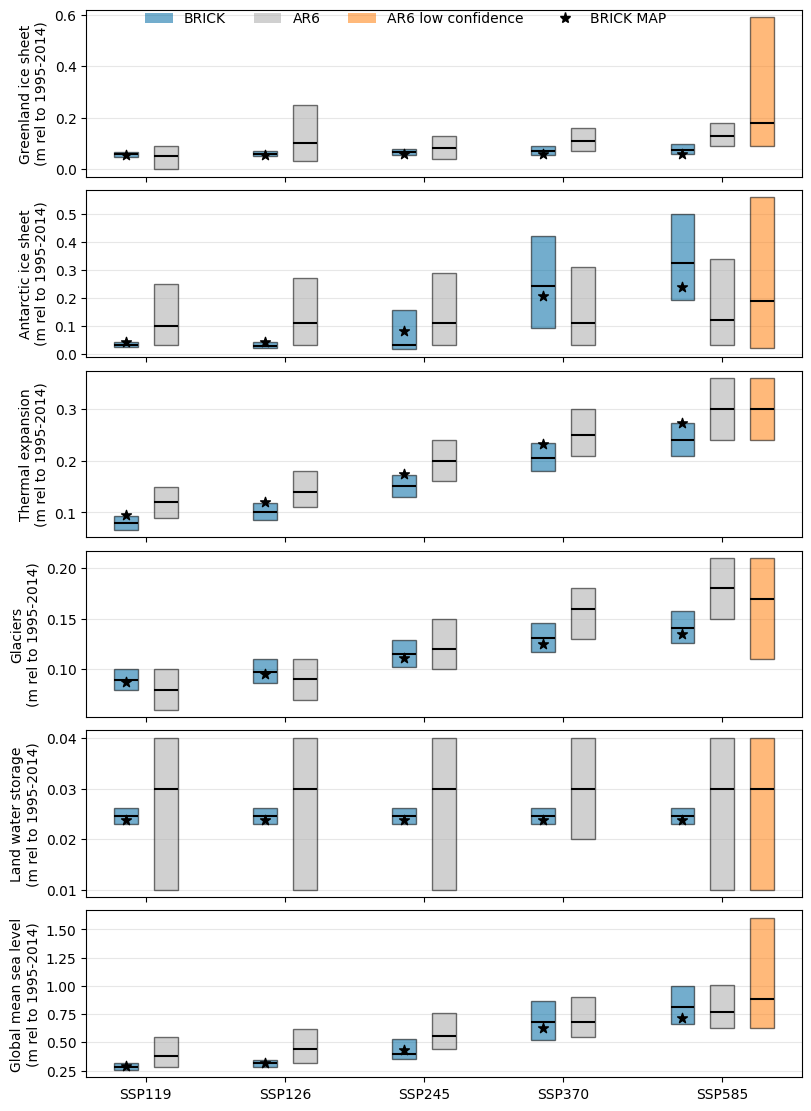

In [15]:
def get_map_value(map_df, year, comp):
    comp_col = comp.upper()
    return map_df.loc[map_df["YEAR"].eq(year), comp_col].iloc[0]


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

model_config = "sneasybrick"
map_year = 2100

scenario_rows = [
    ("ssp119", ["ssp119"]),
    ("ssp126", ["ssp126"]),
    ("ssp245", ["ssp245"]),
    ("ssp370", ["ssp370"]),
    ("ssp585", ["ssp585", "ssp585lc"]),
]

component_titles = {
    "gis": "Greenland ice sheet",
    "ais": "Antarctic ice sheet",
    "te": "Thermal expansion",
    "glac": "Glaciers",
    "lws": "Land water storage",
    "gmsl": "Global mean sea level",
}

def make_box_stats(vals, label):
    p17, p50, p83 = vals
    return {
        "label": label,
        "whislo": p17,
        "q1": p17,
        "med": p50,
        "q3": p83,
        "whishi": p83,
        "fliers": [],
    }

def get_map_value(map_df, year, comp):
    comp_col = comp.upper()
    return map_df.loc[map_df["YEAR"].eq(year), comp_col].iloc[0]

fig, axes = plt.subplots(
    nrows=len(components),
    ncols=1,
    figsize=(8, 11),
    sharex=True,
    constrained_layout=True,
)

for ax, comp in zip(axes, components):

    stats = []
    positions = []
    tick_positions = []
    tick_labels = []

    map_star_x = []
    map_star_y = []

    pos = 1

    for scen, ar6_scens in scenario_rows:

        group_positions = []

        # BRICK likely range
        stats.append(make_box_stats(
            brick_likely[model_config][scen][comp],
            "BRICK"
        ))
        positions.append(pos)
        group_positions.append(pos)

        # BRICK MAP star
        map_star_x.append(pos)
        map_star_y.append(get_map_value(map[model_config][scen], map_year, comp))

        pos += 0.5

        # AR6 likely ranges
        for ar6_scen in ar6_scens:
            label = "AR6 low confidence" if ar6_scen == "ssp585lc" else "AR6"

            stats.append(make_box_stats(
                ar6_likely_comp[ar6_scen][comp],
                label
            ))
            positions.append(pos)
            group_positions.append(pos)

            pos += 0.5

        tick_positions.append(sum(group_positions) / len(group_positions))
        tick_labels.append(scen.upper())

        pos += 0.75

    artists = ax.bxp(
        stats,
        positions=positions,
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        whiskerprops=dict(color="none"),
        capprops=dict(color="none"),
        medianprops=dict(color="black", linewidth=1.5),
    )

    for box, item in zip(artists["boxes"], stats):
        if item["label"] == "BRICK":
            box.set_facecolor("C0")
        elif item["label"] == "AR6 low confidence":
            box.set_facecolor("C1")
        else:
            box.set_facecolor("C2")

        box.set_alpha(0.55)

    ax.scatter(
        map_star_x,
        map_star_y,
        marker="*",
        s=55,
        color="black",
        zorder=5,
        label="MAP",
    )

    ax.set_ylabel(component_titles.get(comp, comp) + "\n(m rel to 1995-2014)")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_labels)

fig.legend(
    handles=[
        Patch(facecolor="C0", alpha=0.55, label="BRICK"),
        Patch(facecolor="C2", alpha=0.55, label="AR6"),
        Patch(facecolor="C1", alpha=0.55, label="AR6 low confidence"),
        plt.Line2D([], [], marker="*", color="black", linestyle="None", markersize=8, label="BRICK MAP"),
    ],
    loc="upper center",
    ncol=4,
    frameon=False,
)

plt.show()

## Compare overall GMSL at different time periods

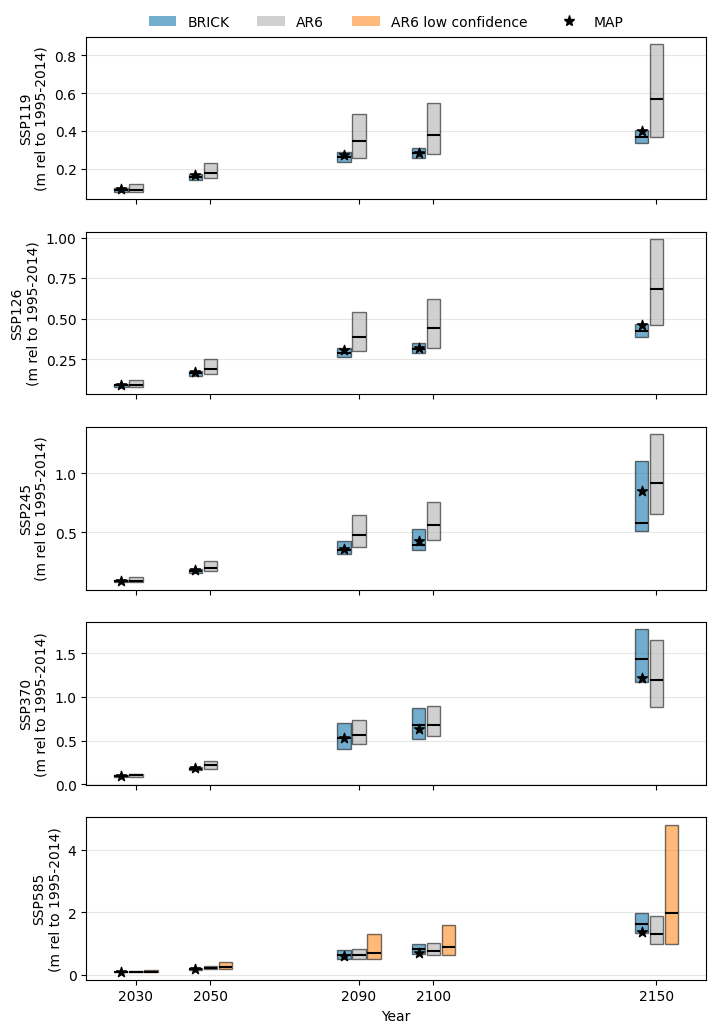

In [21]:
model_config = "sneasybrick"

old_new_scenario_map = {
    "ssp126": "RCP26",
    "ssp245": "RCP45",
    "ssp585": "RCP85",
}

years_plot = [2030, 2050, 2090, 2100, 2150]

year_positions = {
    2030: 0,
    2050: 1,
    2090: 3,
    2100: 4,
    2150: 7,
}

scenario_rows = [
    ("ssp119", ["ssp119"]),
    ("ssp126", ["ssp126"]),
    ("ssp245", ["ssp245"]),
    ("ssp370", ["ssp370"]),
    ("ssp585", ["ssp585", "ssp585lc"]),
]

def make_box_stats(vals, label):
    p17, p50, p83 = vals
    return {
        "label": label,
        "whislo": p17,
        "q1": p17,
        "med": p50,
        "q3": p83,
        "whishi": p83,
        "fliers": [],
    }

def get_map_value(map_df, year):
    return map_df.loc[map_df["YEAR"].eq(year), "GMSL"].iloc[0]

fig, axes = plt.subplots(
    nrows=len(scenario_rows),
    ncols=1,
    figsize=(8, 11.5),
    sharex=True,
    constrained_layout=False,
)

fig.subplots_adjust(top=0.93)

box_width = 0.18

offsets = {
    "BRICK": -0.20,
    "AR6": 0.0,
    "AR6 low confidence": 0.20,
}

for ax, (scen, ar6_scens) in zip(axes, scenario_rows):

    stats = []
    positions = []

    map_star_x = []
    map_star_y = []

    for year in years_plot:

        stats.append(make_box_stats(
            brick_likely_time[model_config][scen][year],
            "BRICK"
        ))
        positions.append(year_positions[year] + offsets["BRICK"])

        map_star_x.append(year_positions[year] + offsets["BRICK"])
        map_star_y.append(get_map_value(map[model_config][scen], year))

        for ar6_scen in ar6_scens:
            label = "AR6 low confidence" if ar6_scen == "ssp585lc" else "AR6"

            stats.append(make_box_stats(
                ar6_likely_time[ar6_scen][year],
                label
            ))
            positions.append(year_positions[year] + offsets[label])

    artists = ax.bxp(
        stats,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        whiskerprops=dict(color="none"),
        capprops=dict(color="none"),
        medianprops=dict(color="black", linewidth=1.5),
    )

    for box, item in zip(artists["boxes"], stats):
        if item["label"] == "BRICK":
            box.set_facecolor("C0")
        elif item["label"] == "AR6 low confidence":
            box.set_facecolor("C1")
        else:
            box.set_facecolor("C2")

        box.set_alpha(0.55)

    ax.scatter(
        map_star_x,
        map_star_y,
        marker="*",
        s=55,
        color="black",
        zorder=5,
    )

    ax.set_ylabel(scen.upper() + "\n(m rel to 1995-2014)")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks([year_positions[y] for y in years_plot])
axes[-1].set_xticklabels(years_plot)
axes[-1].set_xlabel("Year")

fig.legend(
    handles=[
        Patch(facecolor="C0", alpha=0.55, label="BRICK"),
        Patch(facecolor="C2", alpha=0.55, label="AR6"),
        Patch(facecolor="C1", alpha=0.55, label="AR6 low confidence"),
        plt.Line2D([], [], marker="*", color="black", linestyle="None", markersize=8, label="MAP"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=5,
    frameon=False,
)

plt.savefig("figures/brick_ar6_time_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

## Compare to observational calibration data

Make dicts normalized to 1961-1990 and 1992-2001 (AIS) to compare to data

In [22]:
def normalize_ensemble_to_period(years, df, beg_year, end_year):
    """
    Normalize each ensemble member/column to its own mean over beg_year:end_year.
    Returns a copy.
    """
    df_norm = df.copy()

    period_mask = (years >= beg_year) & (years <= end_year)
    period_means = df_norm.loc[period_mask].mean(axis=0, skipna=True)

    df_norm = df_norm - period_means

    return df_norm


def normalize_component_dict(component_dict, years_dict, beg_year, end_year):
    """
    Normalize a nested dict with structure:
        component_dict[model_config][scen] = dataframe

    using years from:
        years_dict[model_config][scen]["YEAR"]
    """
    out = {}

    for model_config in component_dict:
        out[model_config] = {}

        for scen in component_dict[model_config]:
            years = years_dict[model_config][scen]["YEAR"]

            out[model_config][scen] = normalize_ensemble_to_period(
                years,
                component_dict[model_config][scen],
                beg_year,
                end_year,
            )

    return out

In [24]:
gis_obsbase = normalize_component_dict(gis, map, 1961, 1990)
glac_obsbase = normalize_component_dict(glac, map, 1961, 1990)
ais_obsbase = normalize_component_dict(ais, map, 1992, 2001)
gmsl_obsbase = normalize_component_dict(gmsl, map, 1961, 1990)
##te_obsbase = normalize_component_dict(te, map, 1961, 1990) # only have trends for te

In [25]:
model_config = "sneasybrick"
scen = "ssp245"   # hindcast should be identical regardless

# most of the calib data
calib_data = pd.read_csv(
    "https://raw.githubusercontent.com/raddleverse/MimiBRICK.jl/refs/heads/master/data/calibration_data/all_calibration_data_combined.csv"
)

# frederikse et al GIS data
frederikse_url = (
    "https://github.com/raddleverse/MimiBRICK.jl/raw/master/data/calibration_data/global_basin_timeseries.xlsx"
)

frederikse_data = pd.read_excel(
    frederikse_url,
    sheet_name="Global"
)

frederikse_data = frederikse_data.rename(columns={frederikse_data.columns[0]: "year"})

frederikse_years = frederikse_data["year"]

frederikse_greenland_obs = (
    frederikse_data["Greenland Ice Sheet [mean]"] / 1000
)

frederikse_greenland_sigma = (
    (
        frederikse_data["Greenland Ice Sheet [upper]"]
        - frederikse_data["Greenland Ice Sheet [lower]"]
    )
    / 4
    / 1000
)

greenland_norm_mask = (
    (frederikse_years >= 1961)
    & (frederikse_years <= 1990)
)

frederikse_greenland_obs_norm = (
    frederikse_greenland_obs
    - frederikse_greenland_obs.loc[greenland_norm_mask].mean()
)

frederikse_greenland_replacement = pd.DataFrame({
    "year": frederikse_years,
    "merged_greenland_obs": frederikse_greenland_obs_norm,
    "merged_greenland_sigma": frederikse_greenland_sigma,
})

calib_data = calib_data.drop(
    columns=["merged_greenland_obs", "merged_greenland_sigma"]
).merge(
    frederikse_greenland_replacement,
    on="year",
    how="left",
)

In [26]:

def ensemble_stats(df):
    return {
        "median": df.median(axis=1),
        "p17": df.quantile(0.17, axis=1),
        "p83": df.quantile(0.83, axis=1),
    }

def plot_model_vs_obs(
    ax,
    years,
    model_df,
    obs,
    sigma,
    ylabel,
    title=None,
    obs_label="Observations",
    model_label="BRICK median",
    model_color="C0",
):
    stats = ensemble_stats(model_df)

    ax.fill_between(
        years,
        stats["p17"],
        stats["p83"],
        color=model_color,
        alpha=0.25,
        label="17–83%"
    )

    ax.plot(
        years,
        stats["median"],
        color=model_color,
        linewidth=2,
        label=model_label
    )

    ax.errorbar(
        calib_data["year"],
        obs,
        yerr=sigma,
        fmt="k.",
        markersize=2,
        elinewidth=0.5,
        capsize=0,
        alpha=0.7,
        label=obs_label
    )

    ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title)

    ax.grid(alpha=0.3)


years = map[model_config][scen]["YEAR"]

hindcast_mask = (years >= 1850) & (years <= 2020)
years_hindcast = years[hindcast_mask]

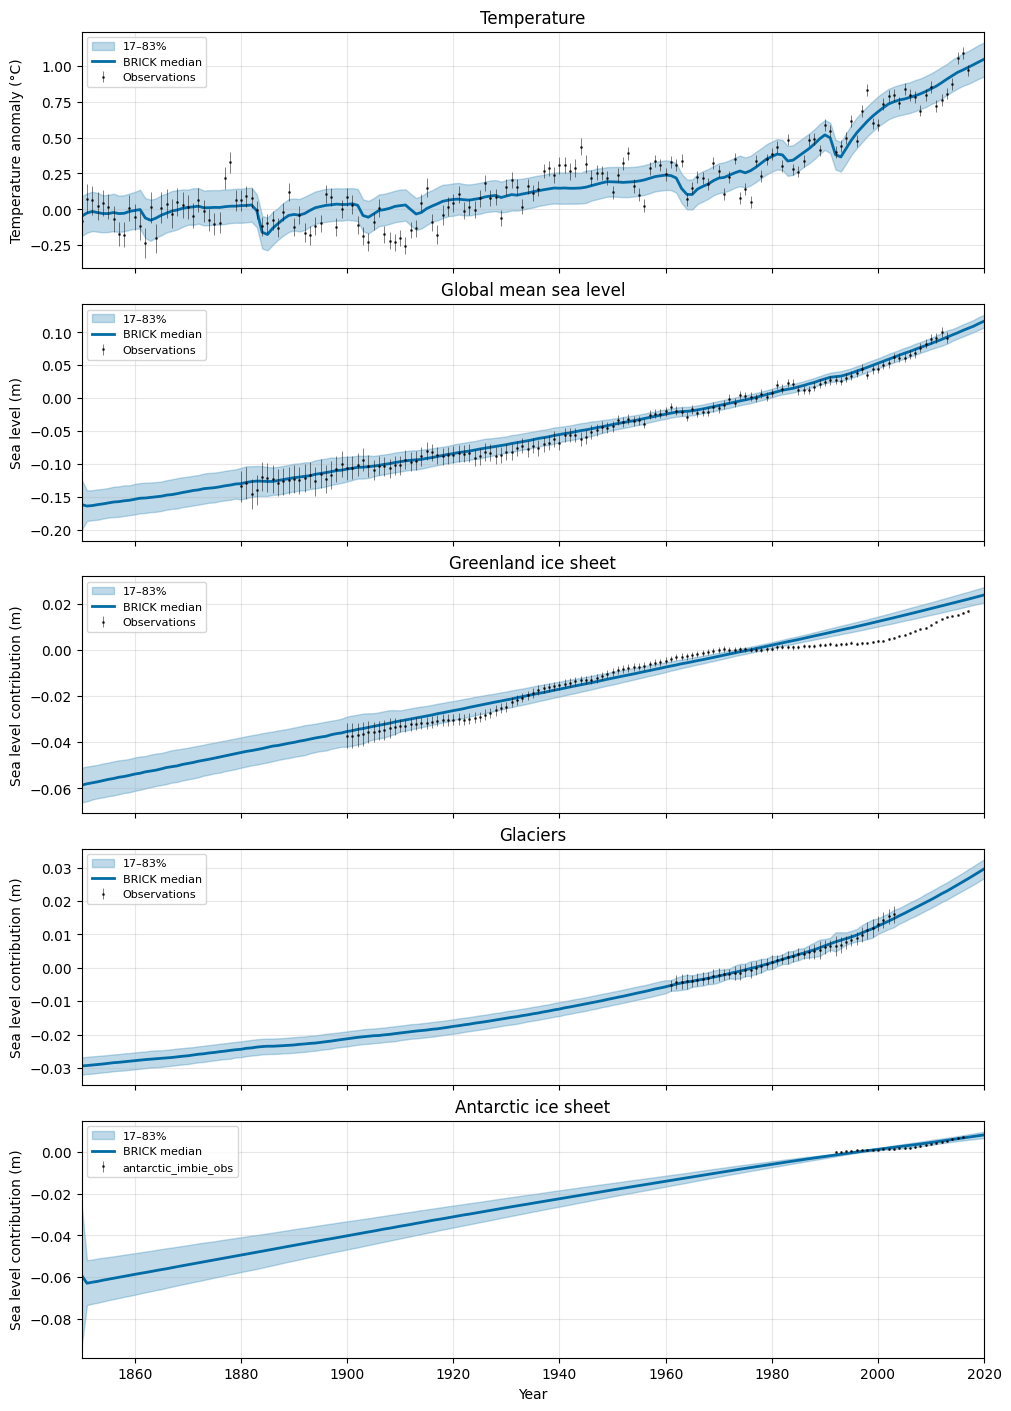

In [27]:

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(10, 14),
    sharex=True,
    constrained_layout=True,
)

plot_model_vs_obs(
    axes[0],
    years_hindcast,
    temp[model_config][scen].loc[hindcast_mask],
    calib_data["hadcrut_temperature_obs"],
    calib_data["hadcrut_temperature_sigma"],
    ylabel="Temperature anomaly (°C)",
    title="Temperature",
)

plot_model_vs_obs(
    axes[1],
    years_hindcast,
    gmsl_obsbase[model_config][scen].loc[hindcast_mask],
    calib_data["gmsl_obs"],
    calib_data["gmsl_sigma"],
    ylabel="Sea level (m)",
    title="Global mean sea level",
)

plot_model_vs_obs(
    axes[2],
    years_hindcast,
    gis_obsbase[model_config][scen].loc[hindcast_mask],
    calib_data["merged_greenland_obs"],
    calib_data["merged_greenland_sigma"],
    ylabel="Sea level contribution (m)",
    title="Greenland ice sheet",
)

plot_model_vs_obs(
    axes[3],
    years_hindcast,
    glac_obsbase[model_config][scen].loc[hindcast_mask],
    calib_data["glaciers_obs"],
    calib_data["glaciers_sigma"],
    ylabel="Sea level contribution (m)",
    title="Glaciers",
)

ais_stats = ensemble_stats(
    ais_obsbase[model_config][scen].loc[hindcast_mask]
)

axes[4].fill_between(
    years_hindcast,
    ais_stats["p17"],
    ais_stats["p83"],
    color="C0",
    alpha=0.25,
    label="17–83%"
)

axes[4].plot(
    years_hindcast,
    ais_stats["median"],
    color="C0",
    linewidth=2,
    label="BRICK median"
)

axes[4].errorbar(
    calib_data["year"],
    calib_data.iloc[:, -6],
    yerr=calib_data.iloc[:, -5],
    fmt=".",
    color="black",
    markersize=2,
    elinewidth=0.5,
    alpha=0.7,
    label=calib_data.columns[-6]
)

axes[4].set_ylabel("Sea level contribution (m)")
axes[4].set_title("Antarctic ice sheet")
axes[4].grid(alpha=0.3)

axes[-1].set_xlabel("Year")
axes[-1].set_xlim(1850, 2020)

for ax in axes:
    ax.legend(loc="upper left", fontsize=8)

plt.show()